# Typed Composition Search — EDA

Exploratory analysis of benchmark results across 4 models × 4 domains × 6 strategies.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

## 1. Load Results

In [2]:
results_dir = Path("../benchmarks/results")

rows = []
query_rows = []
for f in sorted(results_dir.glob("*.json")):
    data = json.loads(f.read_text())
    meta = data["meta"]
    for s in data["strategies"]:
        row = {
            "model": meta["model"],
            "domain": meta["domain"],
            "strategy": s.get("strategy_key", s.get("strategy", "?")),
            "precision": s["precision"],
            "recall": s["recall"],
            "f1": s["f1"],
            "hallucinated": s.get("hallucinated", 0),
            "avg_tools": s.get("avg_tools", 0),
            "total_tools": s.get("total_tools", 0),
            "pruning": s.get("pruning", 0),
            "latency_avg": s.get("latency_avg", 0),
            "avg_prompt_tokens": s.get("avg_prompt_tokens", 0),
            "n": s.get("n", 0),
        }
        rows.append(row)
        for q in s.get("per_query", []):
            query_rows.append({
                "model": meta["model"],
                "domain": meta["domain"],
                "strategy": s.get("strategy_key", s.get("strategy", "?")),
                **q,
            })

df = pd.DataFrame(rows)
qdf = pd.DataFrame(query_rows)
print(f"Strategies: {len(df)} rows, Queries: {len(qdf)} rows")
df.head()

Strategies: 102 rows, Queries: 2832 rows


,model,domain,strategy,precision,recall,f1,hallucinated,avg_tools,total_tools,pruning,latency_avg,avg_prompt_tokens,n
0,claude-haiku,ansible,baseline,0.396190,0.733333,0.477866,0,3.333333,108,0.969136,6645.239376,1845.633333,30
1,claude-haiku,ansible,graph,0.592949,0.526923,0.550916,0,1.666667,108,0.984568,7886.983633,617.633333,30
2,claude-haiku,ansible,graph-narrowed,0.697222,0.612500,0.632242,0,1.533333,108,0.985802,3961.040572,233.766667,30
3,claude-haiku,ansible,graph-probs,0.672917,0.562500,0.593056,0,1.900000,108,0.982407,12077.040693,895.400000,30
4,claude-haiku,ansible,graph-reverse,0.580000,0.461333,0.496762,0,1.433333,108,0.986728,12120.499861,680.200000,30


## 2. Strategy Overview — F1 by Model × Domain

In [3]:
CORE_STRATEGIES = ["baseline", "retrieval", "graph", "graph-reverse-probs", "oracle-graph", "model-types"]
core = df[df["strategy"].isin(CORE_STRATEGIES)].copy()

pivot = core.pivot_table(index=["model", "domain"], columns="strategy", values="f1")
pivot = pivot.reindex(columns=[s for s in CORE_STRATEGIES if s in pivot.columns])
pivot.style.background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1).format("{:.2f}")

## 3. F1 Heatmap

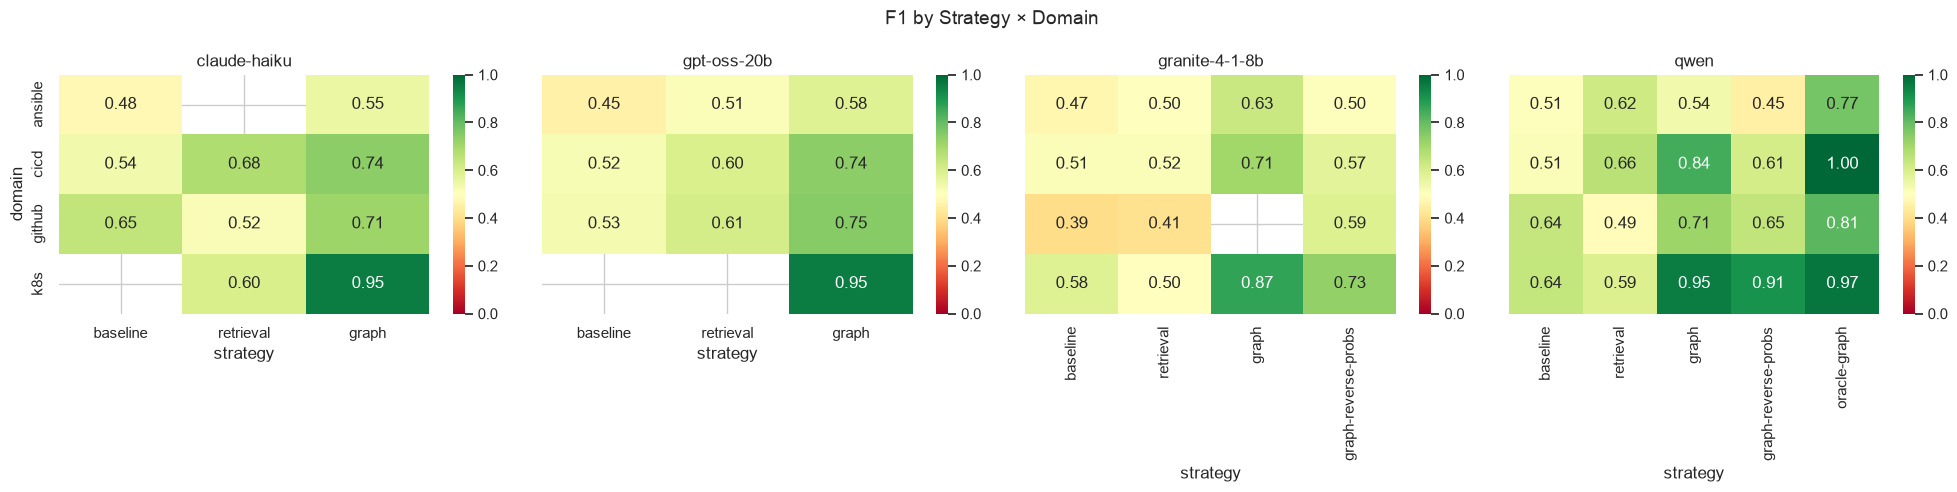

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
models = sorted(core["model"].unique())

for ax, model in zip(axes, models):
    sub = core[core["model"] == model]
    piv = sub.pivot_table(index="domain", columns="strategy", values="f1")
    piv = piv.reindex(columns=[s for s in CORE_STRATEGIES if s in piv.columns])
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
    ax.set_title(model)
    ax.set_ylabel("" if ax != axes[0] else "domain")

fig.suptitle("F1 by Strategy × Domain", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Hallucinations

In [5]:
hal = core.pivot_table(index=["model", "domain"], columns="strategy", values="hallucinated")
hal = hal.reindex(columns=[s for s in CORE_STRATEGIES if s in hal.columns])
hal.style.background_gradient(cmap="RdYlGn_r", axis=None).format("{:.0f}")

## 5. Token Efficiency

In [6]:
tok = core.pivot_table(index=["model", "domain"], columns="strategy", values="avg_prompt_tokens")
tok = tok.reindex(columns=[s for s in CORE_STRATEGIES if s in tok.columns])
tok.style.background_gradient(cmap="RdYlGn_r", axis=None).format("{:.0f}")

## 6. Graph-Forward vs Graph-Reverse-Probs (Planning Direction)

In [7]:
direction = core[core["strategy"].isin(["graph", "graph-reverse-probs"])].copy()
piv = direction.pivot_table(index=["model", "domain"], columns="strategy", values=["f1", "precision", "recall"])
piv

f1                     precision                        recall                    
strategy                   graph graph-reverse-probs     graph graph-reverse-probs     graph graph-reverse-probs
model          domain                                                                                           
claude-haiku   ansible  0.550916                 NaN  0.592949                 NaN  0.526923                 NaN
               cicd     0.740000                 NaN  0.720000                 NaN  0.825000                 NaN
               github   0.714444                 NaN  0.680556                 NaN  0.814444                 NaN
               k8s      0.953125                 NaN  1.000000                 NaN  0.933333                 NaN
gpt-oss-20b    ansible  0.584127                 NaN  0.652083                 NaN  0.556944                 NaN
               cicd     0.739229                 NaN  0.801587                 NaN  0.726190                 NaN
               github   0.746552                 NaN  0.775862                 NaN  0.813793                 NaN
               k8s      0.953125                 NaN  1.000000                 NaN  0.933333                 NaN
granite-4-1-8b ansible  0.630297            0.504762  0.715321            0.590000  0.624638            0.468000
               cicd     0.705882            0.572000  0.823529            0.626667  0.647059            0.570000
               github        NaN            0.588333       NaN            0.605556       NaN            0.653333
               k8s      0.867647            0.727193  0.941176            0.842105  0.839216            0.685088
qwen           ansible  0.535516            0.452762  0.593750            0.510000  0.508333            0.434667
               cicd     0.844444            0.606763  0.870370            0.657971  0.875000            0.652174
               github   0.713690            0.648276  0.744048            0.695402  0.747619            0.682184
               k8s      0.953125            0.909375  1.000000            0.937500  0.933333            0.891667

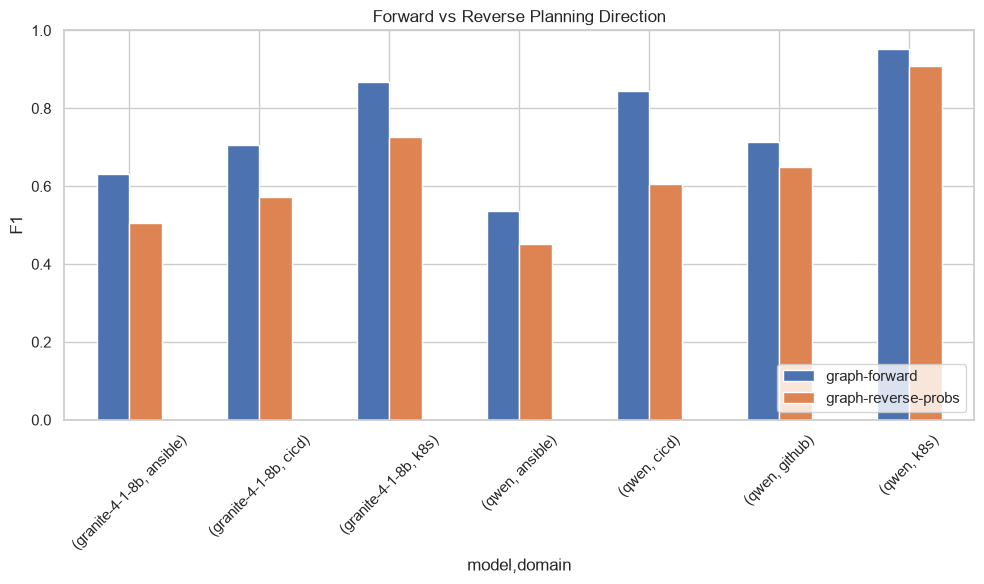

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
fwd = direction[direction["strategy"] == "graph"].set_index(["model", "domain"])["f1"]
rev = direction[direction["strategy"] == "graph-reverse-probs"].set_index(["model", "domain"])["f1"]
comp = pd.DataFrame({"graph-forward": fwd, "graph-reverse-probs": rev}).dropna()
comp.plot.bar(ax=ax, rot=45)
ax.set_ylabel("F1")
ax.set_title("Forward vs Reverse Planning Direction")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Decomposition: Type Prediction × Graph Reachability

In [9]:
oracle = core[core["strategy"] == "oracle-graph"].set_index(["model", "domain"])
types = core[core["strategy"] == "model-types"].set_index(["model", "domain"])
best = core[core["strategy"] == "graph-reverse-probs"].set_index(["model", "domain"])

decomp = pd.DataFrame({
    "oracle_f1": oracle["f1"],
    "type_recall": types["recall"] if "recall" in types.columns else None,
    "e2e_f1": best["f1"],
}).dropna()
decomp

,,oracle_f1,type_recall,e2e_f1
model,domain,,,


## 8. Per-Query Error Analysis

In [10]:
errors = qdf[(qdf["strategy"] == "graph-reverse-probs") & (qdf["f1"] < 1.0)].copy()
if len(errors) > 0:
    print(f"{len(errors)} queries with F1 < 1.0")
    error_cols = ["model", "domain", "id", "category", "expected_source", "expected_target",
                  "predicted_source", "predicted_target", "path_found", "f1"]
    display(errors[[c for c in error_cols if c in errors.columns]].sort_values("f1"))
else:
    print("No errors found")

146 queries with F1 < 1.0


,model,domain,id,category,expected_source,expected_target,predicted_source,predicted_target,path_found,f1
1164,granite-4-1-8b,ansible,launch_job,clean,JobTemplate,Job,?,?,False,-1.000000
1167,granite-4-1-8b,ansible,ambiguous_setup,ambiguous,Role,Task,?,?,False,-1.000000
1175,granite-4-1-8b,ansible,synonym_recipe,synonym,Playbook,PlaybookVars,?,?,False,-1.000000
1173,granite-4-1-8b,ansible,multihop_implicit_collection,multihop,Role,Collection,?,?,False,-1.000000
1176,granite-4-1-8b,ansible,synonym_actions,synonym,Role,Task,?,?,False,-1.000000
...,...,...,...,...,...,...,...,...,...,...
2297,qwen,cicd,ambiguous_release_status,ambiguous,Product,Drop,ProductList,Drop,True,0.800000
2287,qwen,cicd,latest_drop,clean,Product,Drop,ProductKey,Drop,True,0.800000
2056,qwen,ansible,multihop_role_modules,multihop,Role,Module,Role,Task,True,0.800000
2795,qwen,k8s,multihop_node,multihop,Deployment,Node,Deployment,Pod,True,0.800000


## 9. Performance by Query Category

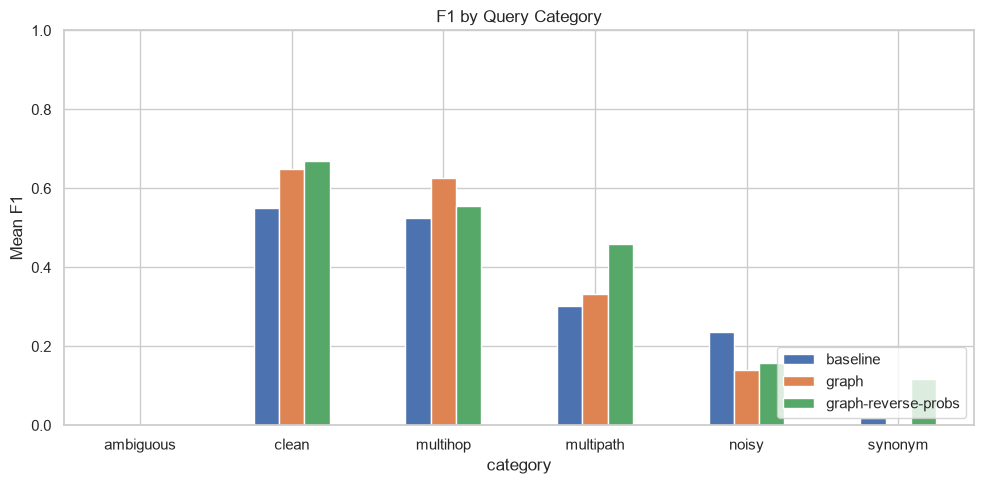

In [11]:
cat_df = qdf[qdf["strategy"].isin(["baseline", "graph", "graph-reverse-probs"])].copy()
if "category" in cat_df.columns:
    cat_f1 = cat_df.groupby(["strategy", "category"])["f1"].mean().unstack("strategy")
    cat_f1 = cat_f1.reindex(columns=["baseline", "graph", "graph-reverse-probs"])
    cat_f1.plot.bar(figsize=(10, 5), rot=0)
    plt.ylabel("Mean F1")
    plt.title("F1 by Query Category")
    plt.ylim(0, 1)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No category column found")

## 10. Cross-Model Variance

In [12]:
variance = core[core["strategy"].isin(["baseline", "graph-reverse-probs"])].copy()
var_stats = variance.groupby(["domain", "strategy"])["f1"].agg(["mean", "std"]).unstack("strategy")
var_stats

mean                           std                    
strategy  baseline graph-reverse-probs  baseline graph-reverse-probs
domain                                                              
ansible   0.477421            0.478762  0.022273            0.036770
cicd      0.521304            0.589382  0.010021            0.024581
github    0.552949            0.618305  0.117798            0.042386
k8s       0.612498            0.818284  0.041806            0.128822